In [1]:
# ============================================================
# D6 - ADVANCED ANALYTICS
# Task 1: Historical VaR + CVaR
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent

# Processed NAV history file
nav_path = PROJECT_ROOT / "data" / "processed" / "02_nav_history_cleaned.csv"

# Load data
nav_df = pd.read_csv(nav_path)

print("✅ NAV data loaded successfully")
print("Shape:", nav_df.shape)
print("\nColumns:")
print(nav_df.columns.tolist())

print("\nFirst 5 rows:")
display(nav_df.head())

✅ NAV data loaded successfully
Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
# ============================================================
# TASK 1A: DAILY RETURNS
# ============================================================

# Make sure date is datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by fund and date
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Calculate daily return for each scheme
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print("✅ Daily returns calculated")

print("\nNumber of schemes:", nav_df["amfi_code"].nunique())
print("Total rows:", len(nav_df))
print("Missing daily returns:", nav_df["daily_return"].isna().sum())

print("\nDaily return summary:")
display(nav_df["daily_return"].describe())

✅ Daily returns calculated

Number of schemes: 40
Total rows: 46000
Missing daily returns: 40

Daily return summary:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [3]:
# ============================================================
# TASK 1B: HISTORICAL VaR (95%) AND CVaR (95%)
# ============================================================

def calculate_var_cvar(returns):
    """Calculate historical 95% VaR and CVaR."""
    
    returns = returns.dropna()
    
    # 5th percentile = Historical VaR threshold
    var_95 = np.percentile(returns, 5)
    
    # Mean of returns at or below VaR
    cvar_95 = returns[returns <= var_95].mean()
    
    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })


# Calculate VaR and CVaR for all 40 schemes
var_cvar_df = (
    nav_df.groupby("amfi_code")["daily_return"]
    .apply(calculate_var_cvar)
    .unstack()
    .reset_index()
)

# Convert to percentage for easier interpretation
var_cvar_df["VaR_95_pct"] = var_cvar_df["VaR_95"] * 100
var_cvar_df["CVaR_95_pct"] = var_cvar_df["CVaR_95"] * 100

# Display results
print("✅ Historical VaR and CVaR calculated")
print("Number of schemes:", len(var_cvar_df))

display(
    var_cvar_df[
        ["amfi_code", "VaR_95_pct", "CVaR_95_pct"]
    ].head(10)
)

✅ Historical VaR and CVaR calculated
Number of schemes: 40


,amfi_code,VaR_95_pct,CVaR_95_pct
0,100016,-1.436364,-1.806021
1,100025,-0.379325,-0.499376
2,100033,-1.903354,-2.345576
3,101206,-1.328166,-1.743943
4,101207,-2.602125,-3.245906
5,101208,-0.026866,-0.042208
6,102885,-1.261263,-1.549041
7,102886,-1.922028,-2.325086
8,102887,-1.523162,-1.941118
9,118632,-1.395405,-1.761858


In [4]:
# ============================================================
# TASK 1C: SAVE VaR + CVaR REPORT
# ============================================================

reports_path = PROJECT_ROOT / "reports"
reports_path.mkdir(parents=True, exist_ok=True)

var_cvar_path = reports_path / "var_cvar_report.csv"

var_cvar_df[
    ["amfi_code", "VaR_95_pct", "CVaR_95_pct"]
].to_csv(var_cvar_path, index=False)

print("✅ VaR + CVaR report saved successfully")
print("File:", var_cvar_path)

✅ VaR + CVaR report saved successfully
File: c:\Users\USER\OneDrive\Desktop\mutual_fund_analytics\reports\var_cvar_report.csv


In [5]:
print(pd.read_csv(var_cvar_path).head())

   amfi_code  VaR_95_pct  CVaR_95_pct
0     100016   -1.436364    -1.806021
1     100025   -0.379325    -0.499376
2     100033   -1.903354    -2.345576
3     101206   -1.328166    -1.743943
4     101207   -2.602125    -3.245906


In [6]:
# ============================================================
# TASK 2A: SELECT 5 KEY FUNDS
# ============================================================

# Select 5 representative funds
key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

print("Selected funds:")
print(key_funds)

# Check that all 5 exist in the NAV data
available_funds = nav_df["amfi_code"].unique()

for fund in key_funds:
    print(f"{fund}: {'✅ Available' if fund in available_funds else '❌ Not found'}")

Selected funds:
[119551, 120503, 118632, 119092, 120841]
119551: ✅ Available
120503: ✅ Available
118632: ✅ Available
119092: ✅ Available
120841: ✅ Available


In [7]:
# ============================================================
# TASK 2B: ROLLING 90-DAY SHARPE RATIO
# ============================================================

rolling_sharpe_df = nav_df[
    nav_df["amfi_code"].isin(key_funds)
].copy()

# Calculate rolling 90-day Sharpe Ratio
rolling_sharpe_df["rolling_sharpe_90"] = (
    rolling_sharpe_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            / x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

# Remove rows where 90 days of data are not available
rolling_sharpe_df = rolling_sharpe_df.dropna(
    subset=["rolling_sharpe_90"]
)

print("✅ Rolling 90-day Sharpe calculated")

print(
    "Funds:",
    rolling_sharpe_df["amfi_code"].nunique()
)

print(
    "Rows:",
    len(rolling_sharpe_df)
)

display(
    rolling_sharpe_df[
        ["amfi_code", "date", "rolling_sharpe_90"]
    ].head(10)
)

✅ Rolling 90-day Sharpe calculated
Funds: 5
Rows: 5300


,amfi_code,date,rolling_sharpe_90
10440,118632,2022-05-09,4.616483
10441,118632,2022-05-10,4.890327
10442,118632,2022-05-11,4.641262
10443,118632,2022-05-12,4.657956
10444,118632,2022-05-13,4.746249
10445,118632,2022-05-16,4.572137
10446,118632,2022-05-17,4.632987
10447,118632,2022-05-18,4.757113
10448,118632,2022-05-19,4.786752
10449,118632,2022-05-20,4.692155


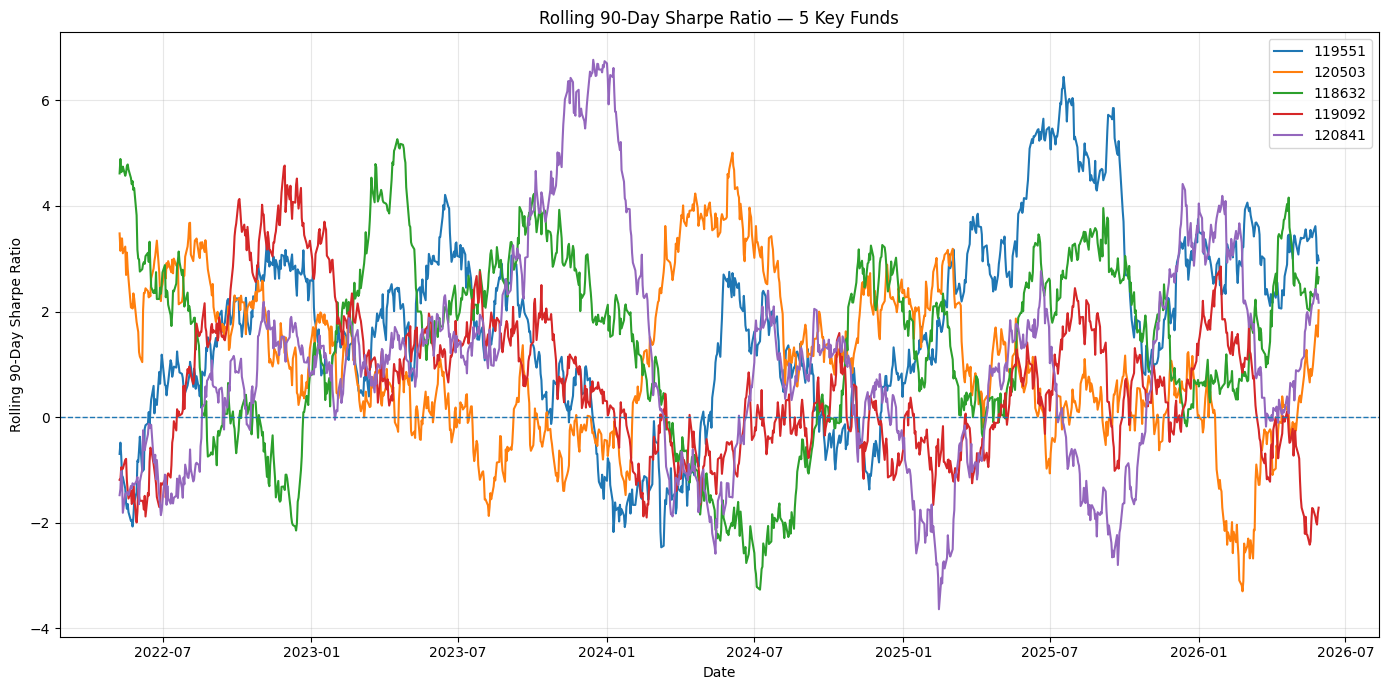

✅ Rolling Sharpe chart saved:
c:\Users\USER\OneDrive\Desktop\mutual_fund_analytics\reports\rolling_sharpe_chart.png


In [8]:
# ============================================================
# TASK 2C: ROLLING 90-DAY SHARPE CHART
# ============================================================

plt.figure(figsize=(14, 7))

for fund in key_funds:
    fund_data = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ].sort_values("date")

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=str(fund)
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
chart_path = reports_path / "rolling_sharpe_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("✅ Rolling Sharpe chart saved:")
print(chart_path)

In [9]:
# ============================================================
# TASK 3A: LOAD INVESTOR TRANSACTIONS
# ============================================================

investor_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "08_investor_transactions_cleaned.csv"
)

investor_df = pd.read_csv(investor_path)

print("✅ Investor transaction data loaded")
print("Shape:", investor_df.shape)

print("\nColumns:")
print(investor_df.columns.tolist())

display(investor_df.head())

✅ Investor transaction data loaded
Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [10]:
# ============================================================
# TASK 3B: INVESTOR COHORT ANALYSIS
# ============================================================

# Convert transaction date
investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"]
)

# Make sure amount is numeric
investor_df["amount_inr"] = pd.to_numeric(
    investor_df["amount_inr"],
    errors="coerce"
)

# Find each investor's first transaction date
first_transaction = (
    investor_df
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

# Merge cohort year back into transactions
investor_df = investor_df.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

print("✅ Investor cohorts created")

display(
    investor_df[
        ["investor_id", "transaction_date", "cohort_year",
         "transaction_type", "amount_inr"]
    ].head(10)
)

✅ Investor cohorts created


,investor_id,transaction_date,cohort_year,transaction_type,amount_inr
0,INV003054,2024-01-01,2024,Sip,1834
1,INV002952,2024-01-01,2024,Redemption,392882
2,INV003420,2024-01-01,2024,Sip,912
3,INV003436,2024-01-01,2024,Sip,1102
4,INV004691,2024-01-01,2024,Lumpsum,8682
5,INV001497,2024-01-01,2024,Sip,3295
6,INV000786,2024-01-01,2024,Sip,15047
7,INV000616,2024-01-01,2024,Sip,933
8,INV003670,2024-01-01,2024,Sip,10672
9,INV002054,2024-01-01,2024,Sip,1111


In [11]:
# ============================================================
# TASK 3C: COHORT METRICS
# ============================================================

# ---- 1. Average SIP amount by cohort ----
sip_transactions = investor_df[
    investor_df["transaction_type"].str.lower() == "sip"
].copy()

avg_sip_by_cohort = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

# ---- 2. Total invested by cohort ----
# Count SIP + Lumpsum as investments
investment_transactions = investor_df[
    investor_df["transaction_type"].str.lower().isin(
        ["sip", "lumpsum"]
    )
].copy()

total_invested_by_cohort = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

# ---- 3. Top fund preference by cohort ----
fund_counts = (
    investment_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    .rename(columns={
        "amfi_code": "top_fund_amfi_code"
    })
)

# ---- Combine all cohort metrics ----
cohort_analysis = (
    avg_sip_by_cohort
    .merge(
        total_invested_by_cohort,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds[
            ["cohort_year", "top_fund_amfi_code",
             "transaction_count"]
        ],
        on="cohort_year",
        how="outer"
    )
    .sort_values("cohort_year")
    .reset_index(drop=True)
)

print("✅ Cohort analysis completed")

display(cohort_analysis)

✅ Cohort analysis completed


,cohort_year,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,transaction_count
0,2024,10996.885825,2258062304,125498,752
1,2025,13505.209581,18992635,119599,11


In [12]:
# ============================================================
# TASK 4: SIP CONTINUITY ANALYSIS
# ============================================================

# Keep only SIP transactions
sip_df = investor_df[
    investor_df["transaction_type"].str.lower() == "sip"
].copy()

# Sort by investor and date
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

# Calculate gap between consecutive SIP transactions
sip_df["gap_days"] = (
    sip_df
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Count SIP transactions and calculate average gap
sip_continuity = (
    sip_df
    .groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

# Keep investors with at least 6 SIP transactions
sip_continuity = sip_continuity[
    sip_continuity["sip_transactions"] >= 6
].copy()

# Flag investors with average gap > 35 days
sip_continuity["continuity_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

print("✅ SIP continuity analysis completed")

print(
    "Investors with 6+ SIP transactions:",
    len(sip_continuity)
)

display(sip_continuity.head(10))

✅ SIP continuity analysis completed
Investors with 6+ SIP transactions: 1362


,investor_id,sip_transactions,avg_gap_days,continuity_status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk
12,INV000013,7,55.333333,At Risk
13,INV000014,7,75.333333,At Risk
22,INV000023,8,58.571429,At Risk
27,INV000028,6,93.600000,At Risk
28,INV000029,7,60.666667,At Risk


In [13]:
# ============================================================
# TASK 4B: SIP CONTINUITY SUMMARY
# ============================================================

total_eligible = len(sip_continuity)

at_risk_count = (
    sip_continuity["continuity_status"]
    .eq("At Risk")
    .sum()
)

regular_count = (
    sip_continuity["continuity_status"]
    .eq("Regular")
    .sum()
)

at_risk_pct = (
    at_risk_count / total_eligible * 100
    if total_eligible > 0 else 0
)

regular_pct = (
    regular_count / total_eligible * 100
    if total_eligible > 0 else 0
)

sip_continuity_summary = pd.DataFrame({
    "Metric": [
        "Investors with 6+ SIP transactions",
        "Regular investors",
        "At-risk investors",
        "Regular continuity rate (%)",
        "At-risk rate (%)"
    ],
    "Value": [
        total_eligible,
        regular_count,
        at_risk_count,
        regular_pct,
        at_risk_pct
    ]
})

display(sip_continuity_summary)

print(f"✅ At-risk rate: {at_risk_pct:.2f}%")
print(f"✅ Regular continuity rate: {regular_pct:.2f}%")

,Metric,Value
0,Investors with 6+ SIP transactions,1362.000000
1,Regular investors,30.000000
2,At-risk investors,1332.000000
3,Regular continuity rate (%),2.202643
4,At-risk rate (%),97.797357


✅ At-risk rate: 97.80%
✅ Regular continuity rate: 2.20%


In [15]:
# ============================================================
# TASK 5A: FIND FUND MASTER + SHARPE FILES
# ============================================================

processed_path = PROJECT_ROOT / "data" / "processed"

print("Files in processed folder:")
for file in processed_path.iterdir():
    print(file.name)

print("\nFiles in reports folder:")
for file in reports_path.iterdir():
    print(file.name)

Files in processed folder:
01_fund_master.csv
02_nav_history.csv
02_nav_history_cleaned.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv

Files in reports folder:
alpha_beta.csv
cagr.csv
data_dictionary.md
data_quality_summary.txt
day1_observations.txt
fund_scorecard.csv
max_drawdown.csv
rolling_sharpe_chart.png
sharpe_ratio.csv
sortino_ratio.csv
var_cvar_report.csv


In [16]:
# ============================================================
# TASK 5A: LOAD DATA FOR FUND RECOMMENDER
# ============================================================

# Load fund master
fund_master_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "01_fund_master.csv"
)

fund_master_df = pd.read_csv(fund_master_path)

# Load Sharpe ratio
sharpe_path = reports_path / "sharpe_ratio.csv"

sharpe_df = pd.read_csv(sharpe_path)

print("✅ Fund master loaded")
print("Shape:", fund_master_df.shape)

print("\nFund master columns:")
print(fund_master_df.columns.tolist())

print("\nSharpe ratio columns:")
print(sharpe_df.columns.tolist())

print("\nFund master sample:")
display(fund_master_df.head())

print("\nSharpe ratio sample:")
display(sharpe_df.head())

✅ Fund master loaded
Shape: (40, 15)

Fund master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Sharpe ratio columns:
['amfi_code', 'Sharpe_Ratio']

Fund master sample:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



Sharpe ratio sample:


,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [17]:
# ============================================================
# TASK 5B: FUND RECOMMENDER
# ============================================================

# Merge fund information with Sharpe ratios
recommender_df = fund_master_df.merge(
    sharpe_df,
    on="amfi_code",
    how="inner"
)

# Map user-friendly risk appetite to dataset risk category
risk_mapping = {
    "Low": "Low",
    "Moderate": "Moderate",
    "High": "Very High"
}

def recommend_funds(risk_appetite):
    """
    Recommend top 3 funds by Sharpe Ratio
    for the selected risk appetite.
    """

    if risk_appetite not in risk_mapping:
        raise ValueError(
            "Risk appetite must be: Low, Moderate, or High"
        )

    risk_category = risk_mapping[risk_appetite]

    recommendations = (
        recommender_df[
            recommender_df["risk_category"] == risk_category
        ]
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
        [[
            "amfi_code",
            "scheme_name",
            "category",
            "plan",
            "risk_category",
            "Sharpe_Ratio"
        ]]
        .reset_index(drop=True)
    )

    return recommendations


# Test all three risk appetites
for appetite in ["Low", "Moderate", "High"]:

    print(f"\n{'=' * 60}")
    print(f"Recommendations for {appetite} Risk Appetite")
    print(f"{'=' * 60}")

    display(recommend_funds(appetite))


Recommendations for Low Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,Regular,Low,0.495723
1,120844,Kotak Liquid Fund - Regular - Growth,Debt,Regular,Low,-0.088747
2,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Regular,Low,-0.226575



Recommendations for Moderate Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular,Moderate,1.448291
1,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,Moderate,1.208267
2,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,Regular,Moderate,1.081659



Recommendations for High Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,149324,DSP Small Cap Fund - Regular - Growth,Equity,Regular,Very High,0.949796
1,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,Very High,0.945308
2,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Regular,Very High,0.448434


In [18]:
# ============================================================
# TASK 6A: LOAD PORTFOLIO HOLDINGS
# ============================================================

portfolio_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "09_portfolio_holdings.csv"
)

portfolio_df = pd.read_csv(portfolio_path)

print("✅ Portfolio holdings loaded")
print("Shape:", portfolio_df.shape)

print("\nColumns:")
print(portfolio_df.columns.tolist())

print("\nFirst 5 rows:")
display(portfolio_df.head())

✅ Portfolio holdings loaded
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [19]:
# ============================================================
# TASK 5B: FUND RECOMMENDER
# ============================================================

# Merge fund information with Sharpe ratios
recommender_df = fund_master_df.merge(
    sharpe_df,
    on="amfi_code",
    how="inner"
)

# Map user-friendly risk appetite to dataset risk category
risk_mapping = {
    "Low": "Low",
    "Moderate": "Moderate",
    "High": "Very High"
}

def recommend_funds(risk_appetite):
    """
    Recommend top 3 funds by Sharpe Ratio
    for the selected risk appetite.
    """

    if risk_appetite not in risk_mapping:
        raise ValueError(
            "Risk appetite must be: Low, Moderate, or High"
        )

    risk_category = risk_mapping[risk_appetite]

    recommendations = (
        recommender_df[
            recommender_df["risk_category"] == risk_category
        ]
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
        [[
            "amfi_code",
            "scheme_name",
            "category",
            "plan",
            "risk_category",
            "Sharpe_Ratio"
        ]]
        .reset_index(drop=True)
    )

    return recommendations


# Test all three risk appetites
for appetite in ["Low", "Moderate", "High"]:

    print(f"\n{'=' * 60}")
    print(f"Recommendations for {appetite} Risk Appetite")
    print(f"{'=' * 60}")

    display(recommend_funds(appetite))


Recommendations for Low Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,Regular,Low,0.495723
1,120844,Kotak Liquid Fund - Regular - Growth,Debt,Regular,Low,-0.088747
2,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Regular,Low,-0.226575



Recommendations for Moderate Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular,Moderate,1.448291
1,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,Moderate,1.208267
2,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,Regular,Moderate,1.081659



Recommendations for High Risk Appetite


,amfi_code,scheme_name,category,plan,risk_category,Sharpe_Ratio
0,149324,DSP Small Cap Fund - Regular - Growth,Equity,Regular,Very High,0.949796
1,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,Very High,0.945308
2,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Regular,Very High,0.448434


In [20]:
# ============================================================
# TASK 6B: SECTOR HHI CONCENTRATION
# ============================================================

# Calculate sector-level weights for each fund
sector_weights = (
    portfolio_df
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

# Convert percentage weights to proportions
sector_weights["sector_weight"] = (
    sector_weights["weight_pct"] / 100
)

# Calculate squared sector weights
sector_weights["squared_weight"] = (
    sector_weights["sector_weight"] ** 2
)

# HHI = sum of squared sector weights
hhi_df = (
    sector_weights
    .groupby("amfi_code")["squared_weight"]
    .sum()
    .reset_index(name="sector_HHI")
)

# Keep only equity funds
equity_funds = fund_master_df[
    fund_master_df["category"].str.lower() == "equity"
][["amfi_code", "scheme_name", "category"]]

hhi_equity = (
    equity_funds
    .merge(hhi_df, on="amfi_code", how="inner")
    .sort_values("sector_HHI", ascending=False)
    .reset_index(drop=True)
)

print("✅ Sector HHI calculated")

print("Number of equity funds:", len(hhi_equity))

display(hhi_equity)

✅ Sector HHI calculated
Number of equity funds: 34


,amfi_code,scheme_name,category,sector_HHI
0,119092,Axis Bluechip Fund - Regular - Growth,Equity,0.296769
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.254992
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,0.253155
3,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,0.251383
4,149323,DSP Midcap Fund - Regular - Growth,Equity,0.241077
5,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.238695
6,118635,Nippon India ETF Nifty 50 BeES,Equity,0.237497
7,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,0.232361
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,0.231464
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.227647


In [21]:
# ============================================================
# TASK 7A: GENERATE KEY NUMBERS FOR ADVANCED INSIGHTS
# ============================================================

# Highest VaR risk
highest_var = var_cvar_df.sort_values(
    "VaR_95_pct"
).iloc[0]

# Highest CVaR risk
highest_cvar = var_cvar_df.sort_values(
    "CVaR_95_pct"
).iloc[0]

# Highest HHI
highest_hhi = hhi_equity.iloc[0]

# Lowest HHI
lowest_hhi = hhi_equity.iloc[-1]

print("Highest VaR risk:")
print(highest_var)

print("\nHighest CVaR risk:")
print(highest_cvar)

print("\nMost concentrated equity fund:")
print(highest_hhi)

print("\nLeast concentrated equity fund:")
print(lowest_hhi)

print("\nCohort analysis:")
display(cohort_analysis)

print("\nSIP continuity:")
display(sip_continuity_summary)

Highest VaR risk:
amfi_code      119599.000000
VaR_95             -0.026859
CVaR_95            -0.032384
VaR_95_pct         -2.685944
CVaR_95_pct        -3.238412
Name: 22, dtype: float64

Highest CVaR risk:
amfi_code      101207.000000
VaR_95             -0.026021
CVaR_95            -0.032459
VaR_95_pct         -2.602125
CVaR_95_pct        -3.245906
Name: 4, dtype: float64

Most concentrated equity fund:
amfi_code                                     119092
scheme_name    Axis Bluechip Fund - Regular - Growth
category                                      Equity
sector_HHI                                  0.296769
Name: 0, dtype: object

Least concentrated equity fund:
amfi_code                                   102886
scheme_name    UTI Mid Cap Fund - Regular - Growth
category                                    Equity
sector_HHI                                 0.12402
Name: 33, dtype: object

Cohort analysis:


,cohort_year,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,transaction_count
0,2024,10996.885825,2258062304,125498,752
1,2025,13505.209581,18992635,119599,11



SIP continuity:


,Metric,Value
0,Investors with 6+ SIP transactions,1362.000000
1,Regular investors,30.000000
2,At-risk investors,1332.000000
3,Regular continuity rate (%),2.202643
4,At-risk rate (%),97.797357


In [22]:
# ============================================================
# D7 — COLLECT FINAL PROJECT RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()

# If notebook is inside notebooks/, move to project root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

reports_path = PROJECT_ROOT / "reports"
processed_path = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("\nReports available:")

for f in sorted(reports_path.iterdir()):
    print(" -", f.name)

print("\nProcessed datasets available:")

for f in sorted(processed_path.iterdir()):
    print(" -", f.name)

Project root: c:\Users\USER\OneDrive\Desktop\mutual_fund_analytics

Reports available:
 - alpha_beta.csv
 - cagr.csv
 - data_dictionary.md
 - data_quality_summary.txt
 - day1_observations.txt
 - fund_scorecard.csv
 - max_drawdown.csv
 - rolling_sharpe_chart.png
 - sharpe_ratio.csv
 - sortino_ratio.csv
 - var_cvar_report.csv

Processed datasets available:
 - 01_fund_master.csv
 - 02_nav_history.csv
 - 02_nav_history_cleaned.csv
 - 03_aum_by_fund_house.csv
 - 04_monthly_sip_inflows.csv
 - 05_category_inflows.csv
 - 06_industry_folio_count.csv
 - 07_scheme_performance_cleaned.csv
 - 08_investor_transactions_cleaned.csv
 - 09_portfolio_holdings.csv
 - 10_benchmark_indices.csv


## Advanced Analytics — Key Insights

### 1. Historical VaR and CVaR

The **SBI Small Cap Fund - Direct Plan - Growth (AMFI 119599)** recorded the largest 95% historical downside VaR at approximately **-2.69%**. This indicates that on the worst 5% of trading days, daily losses can exceed approximately 2.69%. Its CVaR was approximately **-3.24%**, representing the average loss during observations beyond the VaR threshold.

### 2. Investor Cohort Analysis

The **2024 investor cohort** recorded approximately **₹225.81 crore** in total investments, substantially higher than the 2025 cohort's approximately **₹1.90 crore**. The 2024 cohort also had an average SIP amount of approximately **₹10,997**, while the 2025 cohort had a higher average SIP amount of approximately **₹13,505**.

### 3. SIP Continuity Risk

Among **1,362 investors** with at least six SIP transactions, **1,332 investors (97.80%)** were classified as at-risk because their average SIP gap exceeded 35 days. Only **30 investors (2.20%)** showed regular SIP continuity. This indicates a significant SIP continuity issue within the analyzed dataset.

### 4. Sector Concentration

The **Axis Bluechip Fund - Regular - Growth (AMFI 119092)** had the highest sector concentration with an HHI of **0.2968**, indicating relatively greater concentration across sectors. The **UTI Mid Cap Fund - Regular - Growth (AMFI 102886)** had the lowest HHI at **0.1240**, indicating comparatively better sector diversification.

### 5. Risk-Adjusted Fund Recommendations

The recommender ranked funds according to Sharpe Ratio within their risk categories. For the **Moderate** risk category, **Mirae Asset Large Cap Fund - Regular - Growth** achieved the highest Sharpe Ratio among the available funds at approximately **1.4483**, followed by **SBI Bluechip Fund - Regular Plan - Growth** at **1.2083** and **Nippon India Large Cap Fund - Regular - Growth** at **1.0817**. For the High-risk category, DSP Small Cap Fund had the highest Sharpe Ratio at approximately **0.9498**.


In [24]:
# ============================================================
# D7 — LOAD FINAL ANALYTICS RESULTS
# ============================================================

# Load all major performance results
cagr_df = pd.read_csv(reports_path / "cagr.csv")
sharpe_df = pd.read_csv(reports_path / "sharpe_ratio.csv")
sortino_df = pd.read_csv(reports_path / "sortino_ratio.csv")
alpha_beta_df = pd.read_csv(reports_path / "alpha_beta.csv")
drawdown_df = pd.read_csv(reports_path / "max_drawdown.csv")
scorecard_df = pd.read_csv(reports_path / "fund_scorecard.csv")
var_cvar_df = pd.read_csv(reports_path / "var_cvar_report.csv")

print("✅ All major analytics loaded")

print("\n--- CAGR ---")
display(cagr_df.head())

print("\n--- Sharpe ---")
display(sharpe_df.head())

print("\n--- Sortino ---")
display(sortino_df.head())

print("\n--- Alpha + Beta ---")
display(alpha_beta_df.head())

print("\n--- Maximum Drawdown ---")
display(drawdown_df.head())

print("\n--- Fund Scorecard ---")
display(scorecard_df.head())

print("\n--- VaR + CVaR ---")
display(var_cvar_df.head())

✅ All major analytics loaded

--- CAGR ---


,amfi_code,CAGR
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765



--- Sharpe ---


,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661



--- Sortino ---


...

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469



--- Fund Scorecard ---


,amfi_code,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Score
0,120505,1.180101,0.292636,0.000549,-0.181885,47.750
1,148569,1.234930,0.282704,0.018134,-0.163967,47.500
2,149324,0.949796,0.300579,0.011455,-0.311719,46.250
3,119598,0.945308,0.303370,-0.023196,-0.287060,45.875
4,120843,1.306744,0.273305,-0.022830,-0.129740,45.625



--- VaR + CVaR ---


,amfi_code,VaR_95_pct,CVaR_95_pct
0,100016,-1.436364,-1.806021
1,100025,-0.379325,-0.499376
2,100033,-1.903354,-2.345576
3,101206,-1.328166,-1.743943
4,101207,-2.602125,-3.245906
